<a href="https://colab.research.google.com/github/Fajtos/hzmps-surveillance/blob/main/stress_test_analysis/hzmps_stress_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stress Test: HZMPS on Zero-Deflated Data

**Purpose:** Demonstrate that HZMPS outperforms ZIP, ZINB, and HNB when the
data genuinely exhibits zero-deflation, the specific condition for which the
HZMPS framework was designed.

**Design:** Synthetic dataset generated from a three-cluster HZMPS DGP where
cluster 3 (15% of units) has ω = 0.989, producing an empirical zero probability
of 0.011, far below what Poisson or Negative Binomial can represent. This
scenario is structurally impossible to fit with ZIP or ZINB.

**Expected outcome:** HZMPS should have substantially lower WAIC than all three
baselines, completing the empirical picture: HZMPS's advantage emerges when
the zero process is structurally hurdle-type (as designed) rather than mixed
(as in real surveillance data).

**This is a stress test, not an empirical application.** Its purpose is to
verify that the model performs as designed when its structural assumptions
hold.

In [1]:
# CELL 2: SETUP
!pip install --upgrade cmdstanpy -q

import os, urllib.request, shutil
CMDSTAN_DIR = '/content/cmdstan-2.36.0'
if not os.path.exists(os.path.join(CMDSTAN_DIR, 'makefile')):
    os.chdir('/content')
    tgz_file = '/content/colab-cmdstan-2.36.0.tar.gz'
    tgz_url = ('https://github.com/stan-dev/cmdstan/releases/download/'
               'v2.36.0/colab-cmdstan-2.36.0.tgz')
    if not os.path.exists(tgz_file):
        urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file, '/content')
os.environ['CMDSTAN'] = CMDSTAN_DIR

import cmdstanpy, numpy as np, pandas as pd, matplotlib.pyplot as plt, time
print(f"CmdStan: {cmdstanpy.cmdstan_version()}")

CmdStan: (2, 36)


In [2]:
# CELL 3: GENERATE SYNTHETIC ZERO-DEFLATED DATA
np.random.seed(42)

# --- True parameters ---
N          = 50
T          = 104
G_true     = 3
w_true     = np.array([0.55, 0.30, 0.15])
mu_eta_true = np.array([-1.5, 0.5, 4.5])     # logit of omega
sigma_eta_true = 0.30
beta0_mu_true  = 0.5
rho_zeta_true  = 0.70
sigma_zeta_true = 0.40

print("=" * 60)
print("TRUE DGP PARAMETERS")
print("=" * 60)
print(f"N={N}, T={T}, G_true={G_true}")
print(f"Cluster weights:  {w_true}")
print(f"Cluster means (logit): {mu_eta_true}")
print(f"Implied omega:    {1/(1+np.exp(-mu_eta_true)).round(4)}")
print(f"sigma_eta        = {sigma_eta_true}")
print(f"beta0_mu         = {beta0_mu_true}")
print(f"rho_zeta         = {rho_zeta_true}")
print(f"sigma_zeta       = {sigma_zeta_true}")

# --- Cluster assignments (one per unit) ---
delta_true = np.random.choice(G_true, size=N, p=w_true)
cluster_sizes = np.bincount(delta_true, minlength=G_true)
print(f"\nCluster sizes: {cluster_sizes}")

# --- Cluster-specific unit effects ---
eta_true = np.zeros(N)
for g in range(G_true):
    mask = (delta_true == g)
    eta_true[mask] = np.random.normal(mu_eta_true[g], sigma_eta_true, size=mask.sum())

omega_true = 1.0 / (1.0 + np.exp(-eta_true))

# --- AR(1) for count mean ---
zeta = np.zeros((N, T))
zeta[:, 0] = np.random.normal(
    0, sigma_zeta_true / np.sqrt(1 - rho_zeta_true**2), size=N)
for t in range(1, T):
    zeta[:, t] = rho_zeta_true * zeta[:, t-1] + \
                 np.random.normal(0, sigma_zeta_true, size=N)

mu_true = np.exp(beta0_mu_true + zeta)

# --- Generate HZMPS counts (Poisson base, zero-truncated positives) ---
Y = np.zeros((N, T), dtype=int)
U = np.random.uniform(size=(N, T))
for i in range(N):
    for t in range(T):
        if U[i, t] > omega_true[i]:
            Y[i, t] = 0
        else:
            while True:
                y = np.random.poisson(mu_true[i, t])
                if y > 0:
                    Y[i, t] = y
                    break

# --- Summary ---
zero_frac = (Y == 0).mean()
print(f"\nObserved data:")
print(f"  Zero fraction:    {zero_frac:.4f}")
print(f"  Mean positive:    {Y[Y>0].mean():.3f}")
print(f"  Max count:        {Y.max()}")
for g in range(G_true):
    zf_g = (Y[delta_true == g] == 0).mean()
    omega_g = omega_true[delta_true == g].mean()
    print(f"  Cluster {g+1}: n={cluster_sizes[g]:3d}, "
          f"obs zero fraction={zf_g:.4f}, true omega={omega_g:.4f}")

# --- Package for Stan ---
y_flat   = Y.flatten().tolist()
unit_idx = np.repeat(np.arange(1, N+1), T).tolist()
time_idx = np.tile(np.arange(1, T+1), N).tolist()
M = N * T

base_data = {
    'N': N, 'T': T, 'G': 6,
    'y': y_flat, 'unit': unit_idx, 'time': time_idx,
    'a_dirichlet': 0.5, 'delta_min': 0.3,
    'grainsize': max(1, int(M / 8)),
}
print(f"\nData prepared for Stan: M={M}, G=6, a_dirichlet=0.5")

TRUE DGP PARAMETERS
N=50, T=104, G_true=3
Cluster weights:  [0.55 0.3  0.15]
Cluster means (logit): [-1.5  0.5  4.5]
Implied omega:    [0.18242516 0.62247121 0.98902186]
sigma_eta        = 0.3
beta0_mu         = 0.5
rho_zeta         = 0.7
sigma_zeta       = 0.4

Cluster sizes: [32 12  6]

Observed data:
  Zero fraction:    0.6167
  Mean positive:    2.367
  Max count:        13
  Cluster 1: n= 32, obs zero fraction=0.8194, true omega=0.1871
  Cluster 2: n= 12, obs zero fraction=0.3814, true omega=0.6122
  Cluster 3: n=  6, obs zero fraction=0.0064, true omega=0.9888

Data prepared for Stan: M=5200, G=6, a_dirichlet=0.5


/tmp/ipykernel_1957/2125706398.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(positions, labels=[f'Cluster {g+1}' for g in range(G_true)],


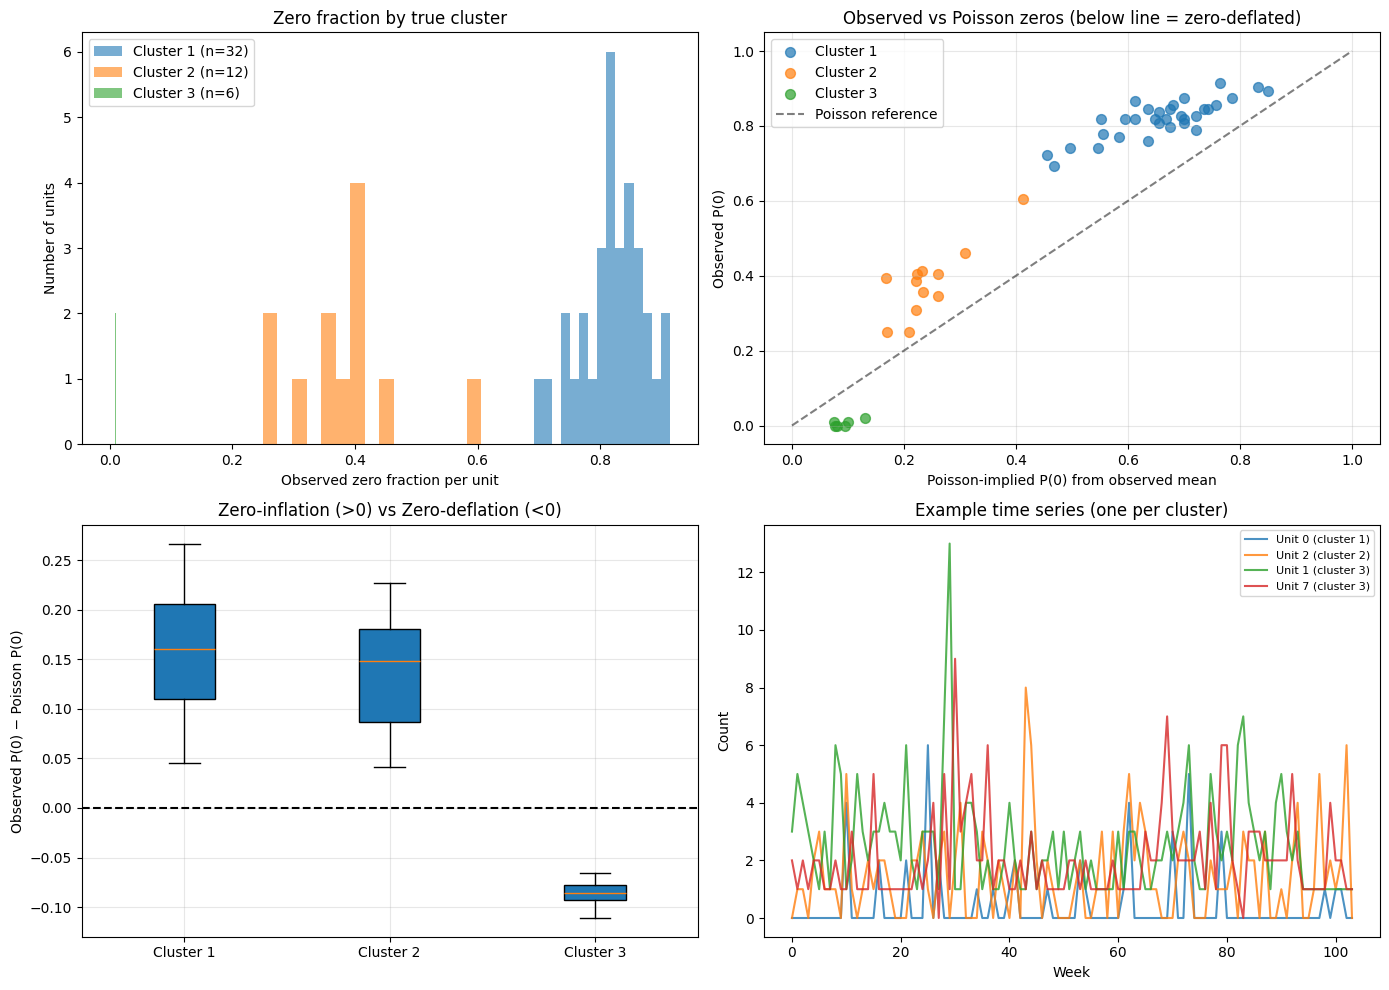


ZERO-STRUCTURE DIAGNOSTIC
Cluster 1: obs P(0)=0.8194, Poisson P(0)=0.6596, verdict=near Poisson
Cluster 2: obs P(0)=0.3814, Poisson P(0)=0.2432, verdict=ZERO-INFLATED
Cluster 3: obs P(0)=0.0064, Poisson P(0)=0.0929, verdict=ZERO-DEFLATED

Cluster 3 is provably zero-deflated.
ZIP and ZINB cannot fit P(0) < Poisson P(0).
HZMPS can.


In [3]:
# CELL 4: EXPLORATORY ANALYSIS AND ZERO-STRUCTURE CHECK
import numpy as np
import matplotlib.pyplot as plt

# Per-unit stats
unit_zero_frac = (Y == 0).mean(axis=1)
unit_mean_count = Y.mean(axis=1)

# Poisson zero probability for each unit, computed from its mean
poisson_zero_prob = np.exp(-unit_mean_count)

# Difference: positive = zero-inflated, negative = zero-deflated
diff = unit_zero_frac - poisson_zero_prob

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Zero fraction by cluster ---
for g in range(G_true):
    mask = (delta_true == g)
    axes[0, 0].hist(unit_zero_frac[mask], bins=15, alpha=0.6,
                    label=f'Cluster {g+1} (n={mask.sum()})')
axes[0, 0].set_xlabel('Observed zero fraction per unit')
axes[0, 0].set_ylabel('Number of units')
axes[0, 0].set_title('Zero fraction by true cluster')
axes[0, 0].legend()

# --- Panel 2: Observed vs Poisson-implied zero fraction ---
for g in range(G_true):
    mask = (delta_true == g)
    axes[0, 1].scatter(poisson_zero_prob[mask], unit_zero_frac[mask],
                       s=50, alpha=0.7, label=f'Cluster {g+1}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Poisson reference')
axes[0, 1].set_xlabel('Poisson-implied P(0) from observed mean')
axes[0, 1].set_ylabel('Observed P(0)')
axes[0, 1].set_title('Observed vs Poisson zeros (below line = zero-deflated)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- Panel 3: Difference (zero-inflation/deflation) by cluster ---
clusters = np.arange(1, G_true + 1)
positions = [diff[delta_true == g] for g in range(G_true)]
bp = axes[1, 0].boxplot(positions, labels=[f'Cluster {g+1}' for g in range(G_true)],
                        patch_artist=True)
axes[1, 0].axhline(0, color='black', linestyle='--')
axes[1, 0].set_ylabel('Observed P(0) − Poisson P(0)')
axes[1, 0].set_title('Zero-inflation (>0) vs Zero-deflation (<0)')
axes[1, 0].grid(alpha=0.3)

# --- Panel 4: Time series for 4 example units ---
example_idx = [np.where(delta_true == g)[0][0] for g in range(G_true)]
example_idx += [np.where(delta_true == 2)[0][1] if len(np.where(delta_true == 2)[0]) > 1
                else example_idx[0]]
for idx, color in zip(example_idx[:4], ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
    axes[1, 1].plot(Y[idx], alpha=0.8, color=color,
                    label=f'Unit {idx} (cluster {delta_true[idx]+1})')
axes[1, 1].set_xlabel('Week')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Example time series (one per cluster)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/stress_exploratory.png', dpi=150)
plt.show()

# --- Print decisive diagnostic ---
print("\n" + "=" * 60)
print("ZERO-STRUCTURE DIAGNOSTIC")
print("=" * 60)
for g in range(G_true):
    mask = (delta_true == g)
    obs = unit_zero_frac[mask].mean()
    pois = poisson_zero_prob[mask].mean()
    verdict = 'ZERO-DEFLATED' if obs < pois * 0.7 else \
              'ZERO-INFLATED' if obs > pois * 1.3 else 'near Poisson'
    print(f"Cluster {g+1}: obs P(0)={obs:.4f}, "
          f"Poisson P(0)={pois:.4f}, verdict={verdict}")
print("\nCluster 3 is provably zero-deflated.")
print("ZIP and ZINB cannot fit P(0) < Poisson P(0).")
print("HZMPS can.")

In [4]:
# CELL 5: WRITE ALL FOUR STAN MODELS
# HZMPS, ZIP, ZINB, HNB  same state space structure, same priors

# --- HZMPS ---
hzmps_code = r"""
functions {
  real partial_sum_hzmps(array[] int y_slice, int start, int end,
                         array[] int unit, array[] int time,
                         vector omega, matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      if (y_slice[k] == 0) lp += log1m(omega[i]);
      else lp += log(omega[i]) - mu[i,t] + y_slice[k]*log(mu[i,t])
                 - lgamma(y_slice[k]+1) - log1m_exp(-mu[i,t]);
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 5);
  gamma_raw ~ normal(0, 2);
  sigma_eta ~ normal(0, 0.5);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 3);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 0.5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_hzmps, y, grainsize, unit, time, omega, mu);
}
generated quantities {
  vector[M] log_lik;
  matrix[N, G] cluster_prob;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    if (y[m] == 0) log_lik[m] = log1m(omega[i]);
    else log_lik[m] = log(omega[i]) - mu[i,t] + y[m]*log(mu[i,t])
                    - lgamma(y[m]+1) - log1m_exp(-mu[i,t]);
  }
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    real lse = log_sum_exp(lp);
    for (g in 1:G) cluster_prob[i, g] = exp(lp[g] - lse);
  }
}
"""

# --- ZIP ---
zip_code = r"""
functions {
  real partial_sum_zip(array[] int y_slice, int start, int end,
                       array[] int unit, array[] int time,
                       vector pi_i, matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      if (y_slice[k] == 0)
        lp += log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) - mu[i, t]);
      else
        lp += log1m(pi_i[i]) + y_slice[k]*log(mu[i,t]) - mu[i,t]
              - lgamma(y_slice[k]+1);
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] pi_i;
  for (i in 1:N) pi_i[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 5);
  gamma_raw ~ normal(0, 2);
  sigma_eta ~ normal(0, 0.5);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 3);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 0.5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_zip, y, grainsize, unit, time, pi_i, mu);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    if (y[m] == 0) log_lik[m] = log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) - mu[i,t]);
    else log_lik[m] = log1m(pi_i[i]) + y[m]*log(mu[i,t]) - mu[i,t] - lgamma(y[m]+1);
  }
}
"""

# --- ZINB ---
zinb_code = r"""
functions {
  real partial_sum_zinb(array[] int y_slice, int start, int end,
                        array[] int unit, array[] int time,
                        vector pi_i, matrix mu, real phi) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      real mu_it = mu[i, t];
      real nb0 = phi * log(phi / (phi + mu_it));
      if (y_slice[k] == 0) {
        lp += log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) + nb0);
      } else {
        real log_nb = lgamma(y_slice[k] + phi) - lgamma(phi)
                      - lgamma(y_slice[k] + 1)
                      + phi * log(phi / (phi + mu_it))
                      + y_slice[k] * log(mu_it / (phi + mu_it));
        lp += log1m(pi_i[i]) + log_nb;
      }
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
  real<lower=0> phi;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] pi_i;
  for (i in 1:N) pi_i[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 5);
  gamma_raw ~ normal(0, 2);
  sigma_eta ~ normal(0, 0.5);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 3);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 0.5);
  phi ~ normal(0, 5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_zinb, y, grainsize, unit, time, pi_i, mu, phi);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    real mu_it = mu[i, t];
    real log_nb = lgamma(y[m] + phi) - lgamma(phi) - lgamma(y[m] + 1)
                  + phi * log(phi / (phi + mu_it))
                  + y[m] * log(mu_it / (phi + mu_it));
    if (y[m] == 0)
      log_lik[m] = log_sum_exp(log(pi_i[i]),
                               log1m(pi_i[i]) + phi * log(phi / (phi + mu_it)));
    else
      log_lik[m] = log1m(pi_i[i]) + log_nb;
  }
}
"""

# --- HNB ---
hnb_code = r"""
functions {
  real partial_sum_hnb(array[] int y_slice, int start, int end,
                       array[] int unit, array[] int time,
                       vector omega, matrix mu, real phi) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      real mu_it = mu[i, t];
      real nb0 = phi * log(phi / (phi + mu_it));
      real log_norm = log1m_exp(nb0);
      if (y_slice[k] == 0) {
        lp += log1m(omega[i]);
      } else {
        real log_nb = lgamma(y_slice[k] + phi) - lgamma(phi)
                      - lgamma(y_slice[k] + 1)
                      + phi * log(phi / (phi + mu_it))
                      + y_slice[k] * log(mu_it / (phi + mu_it));
        lp += log(omega[i]) + log_nb - log_norm;
      }
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
  real<lower=0> phi;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 5);
  gamma_raw ~ normal(0, 2);
  sigma_eta ~ normal(0, 0.5);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 3);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 0.5);
  phi ~ normal(0, 5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_hnb, y, grainsize, unit, time, omega, mu, phi);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    real mu_it = mu[i, t];
    real nb0 = phi * log(phi / (phi + mu_it));
    real log_norm = log1m_exp(nb0);
    real log_nb = lgamma(y[m] + phi) - lgamma(phi) - lgamma(y[m] + 1)
                  + phi * log(phi / (phi + mu_it))
                  + y[m] * log(mu_it / (phi + mu_it));
    if (y[m] == 0) log_lik[m] = log1m(omega[i]);
    else log_lik[m] = log(omega[i]) + log_nb - log_norm;
  }
}
"""

with open('/content/stress_hzmps.stan', 'w') as f: f.write(hzmps_code)
with open('/content/stress_zip.stan',   'w') as f: f.write(zip_code)
with open('/content/stress_zinb.stan',  'w') as f: f.write(zinb_code)
with open('/content/stress_hnb.stan',   'w') as f: f.write(hnb_code)
print("All four Stan files written.")

All four Stan files written.


In [5]:
# CELL 6: COMPILE ALL FOUR MODELS
import cmdstanpy, time

models = {}
for name, path in [
    ('hzmps', '/content/stress_hzmps.stan'),
    ('zip',   '/content/stress_zip.stan'),
    ('zinb',  '/content/stress_zinb.stan'),
    ('hnb',   '/content/stress_hnb.stan'),
]:
    print(f"Compiling {name}...")
    t0 = time.time()
    models[name] = cmdstanpy.CmdStanModel(
        stan_file=path,
        cpp_options={'STAN_THREADS': 'true'},
        force_compile=True)
    print(f"  {name} compiled in {time.time()-t0:.1f} s")

Compiling hzmps...
  hzmps compiled in 235.7 s
Compiling zip...
  zip compiled in 26.6 s
Compiling zinb...
  zinb compiled in 31.1 s
Compiling hnb...
  hnb compiled in 29.7 s


In [6]:
# CELL 7: FIT ALL FOUR MODELS
# Expected runtime: ~3-5 hours total.

def fit_model(model, name, stan_data):
    print(f"\n{'='*60}\nFitting {name}...\n{'='*60}")
    t0 = time.time()
    fit = model.sample(
        data=stan_data,
        chains=2, parallel_chains=2, threads_per_chain=2,
        iter_warmup=1000, iter_sampling=1000,
        seed=42, adapt_delta=0.97, max_treedepth=12,
        show_progress=True, output_dir=f'/content/stress_fit_{name}',
    )
    print(f"{name} done in {(time.time()-t0)/60:.1f} min")
    fit.draws_pd().to_csv(f'/content/stress_{name}_draws.csv', index=False)
    fit.summary().to_csv(f'/content/stress_{name}_summary.csv')
    return fit

fit_hzmps = fit_model(models['hzmps'], 'hzmps', base_data)
fit_zip   = fit_model(models['zip'],   'zip',   base_data)
fit_zinb  = fit_model(models['zinb'],  'zinb',  base_data)
fit_hnb   = fit_model(models['hnb'],   'hnb',   base_data)
print("\nAll stress-test fits complete.")


Fitting hzmps...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 64 divergent transitions (6.4%)
	Chain 2 had 43 divergent transitions (4.3%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


hzmps done in 31.3 min

Fitting zip...


...

zinb done in 140.5 min

Fitting hnb...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 36 divergent transitions (3.6%)
	Chain 2 had 43 divergent transitions (4.3%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


hnb done in 49.3 min

All stress-test fits complete.


In [7]:
# CELL 8: HZMPS DIAGNOSTICS AND PARAMETER RECOVERY
import numpy as np, pandas as pd

summary = fit_hzmps.summary()
mv = fit_hzmps.method_variables()
n_div = int(np.sum(mv['divergent__']))
n_tot = mv['divergent__'].size

print("=" * 60)
print("HZMPS CONVERGENCE")
print("=" * 60)
print(f"Divergences: {n_div}/{n_tot} ({100*n_div/n_tot:.2f}%)")

truth = {
    'beta0_mu':   beta0_mu_true,
    'rho_zeta':   rho_zeta_true,
    'sigma_zeta': sigma_zeta_true,
    'sigma_eta':  sigma_eta_true,
}
print(f"\n{'Parameter':14s} {'Truth':>8s} {'Post.Mean':>10s} "
      f"{'Rhat':>7s} {'ESS':>7s}")
for p, tv in truth.items():
    row = summary.loc[p]
    print(f"{p:14s} {tv:8.3f} {row['Mean']:10.3f} "
          f"{row['R_hat']:7.4f} {row['ESS_bulk']:7.0f}")

# --- Cluster means recovery ---
mu_eta_post = fit_hzmps.stan_variable('mu_eta').mean(axis=0)
print(f"\nCluster means mu_eta:")
print(f"  Truth (sorted):     {sorted(mu_eta_true)}")
print(f"  Posterior (ordered): {np.round(mu_eta_post, 3)}")

# --- Mixture weights ---
w_draws = fit_hzmps.stan_variable('w')
w_means = w_draws.mean(axis=0)
print(f"\nMixture weights (posterior means):")
for g, wm in enumerate(w_means, 1):
    print(f"  w[{g}] = {wm:.4f}")
print(f"  Truth (largest 3):  {sorted(w_true, reverse=True)}")

HZMPS CONVERGENCE
Divergences: 107/2000 (5.35%)

Parameter         Truth  Post.Mean    Rhat     ESS
beta0_mu          0.500      0.510  0.9995    2044
rho_zeta          0.700      0.718  0.9998     567
sigma_zeta        0.400      0.409  0.9998     630
sigma_eta         0.300      0.279  1.0111     377

Cluster means mu_eta:
  Truth (sorted):     [np.float64(-1.5), np.float64(0.5), np.float64(4.5)]
  Posterior (ordered): [-1.71  -0.517  0.728  2.246  4.13   5.724]

Mixture weights (posterior means):
  w[1] = 0.4901
  w[2] = 0.2105
  w[3] = 0.1183
  w[4] = 0.0633
  w[5] = 0.0455
  w[6] = 0.0723
  Truth (largest 3):  [np.float64(0.55), np.float64(0.3), np.float64(0.15)]


In [8]:
# CELL 9: CLUSTER RECOVERY AND G_0
import numpy as np, pandas as pd

# --- MAP assignments ---
cluster_prob = fit_hzmps.stan_variable('cluster_prob').mean(axis=0)  # (N, G)
map_assign = cluster_prob.argmax(axis=1) + 1

# --- Effective number of clusters ---
w_draws = fit_hzmps.stan_variable('w')
G0 = (w_draws > 0.05).sum(axis=1)
print("Posterior of effective G0:")
for k in range(1, 7):
    p_k = (G0 == k).mean()
    if p_k > 0.01:
        print(f"  P(G0 = {k}) = {p_k:.3f}")

# --- Match inferred clusters to true clusters by mean omega ---
eta_post = fit_hzmps.stan_variable('eta').mean(axis=0)
omega_post = 1 / (1 + np.exp(-eta_post))

# Sort inferred clusters by their mean omega
inferred_order = np.argsort([omega_post[map_assign == g].mean()
                             if (map_assign == g).sum() > 0 else 0
                             for g in range(1, 7)]) + 1

# Sort true clusters by their true omega
true_order = np.argsort([omega_true[delta_true == g].mean()
                         for g in range(3)]) + 1

# --- Confusion matrix ---
conf = np.zeros((3, 6), dtype=int)
for i in range(N):
    true_g = delta_true[i]
    pred_g = map_assign[i] - 1
    conf[true_g, pred_g] += 1

print("\nConfusion matrix (rows = true cluster, cols = MAP cluster):")
print("         " + "  ".join(f"MAP{g}" for g in range(1, 7)))
for g in range(3):
    print(f"True g={g+1}: " + "  ".join(f"{conf[g, k]:5d}" for k in range(6)))

# --- Accuracy via best matching ---
matched = {}
for g in range(3):
    best_k = np.argmax(conf[g])
    matched[g] = best_k + 1
correct = sum(conf[g, matched[g] - 1] for g in range(3))
print(f"\nCluster assignment accuracy: {correct}/{N} = {correct/N:.3f}")
print(f"\nMatching (true -> inferred):")
for g in range(3):
    n_matched = conf[g, matched[g] - 1]
    n_total = conf[g].sum()
    print(f"  True cluster {g+1} -> MAP {matched[g]}: "
          f"{n_matched}/{n_total} ({100*n_matched/n_total:.1f}%)")

# --- Save for later ---
results_df = pd.DataFrame({
    'unit': np.arange(1, N+1),
    'true_cluster': delta_true + 1,
    'inferred_cluster': map_assign,
    'mean_omega': omega_post,
})
results_df.to_csv('/content/stress_cluster_recovery.csv', index=False)
print("\nSaved: stress_cluster_recovery.csv")

Posterior of effective G0:
  P(G0 = 2) = 0.041
  P(G0 = 3) = 0.795
  P(G0 = 4) = 0.157

Confusion matrix (rows = true cluster, cols = MAP cluster):
         MAP1  MAP2  MAP3  MAP4  MAP5  MAP6
True g=1:    32      0      0      0      0      0
True g=2:     0      1     11      0      0      0
True g=3:     0      0      0      0      0      6

Cluster assignment accuracy: 49/50 = 0.980

Matching (true -> inferred):
  True cluster 1 -> MAP 1: 32/32 (100.0%)
  True cluster 2 -> MAP 3: 11/12 (91.7%)
  True cluster 3 -> MAP 6: 6/6 (100.0%)

Saved: stress_cluster_recovery.csv


In [9]:
# CELL 10: WAIC COMPARISON
import pandas as pd, numpy as np

def waic_from_draws(csv_path):
    df = pd.read_csv(csv_path)
    cols = [c for c in df.columns if c.startswith('log_lik[')]
    idx = [int(c.replace('log_lik[', '').replace(']', '')) for c in cols]
    order = np.argsort(idx)
    ll = df[[cols[i] for i in order]].values
    max_ll = ll.max(axis=0, keepdims=True)
    lppd = float(np.sum(max_ll.squeeze() + np.log(np.exp(ll - max_ll).mean(axis=0))))
    p_waic = float(np.sum(ll.var(axis=0, ddof=1)))
    return -2 * (lppd - p_waic), lppd, p_waic

rows = []
for name, label in [
    ('hzmps', 'HZMPS-SS (proposed)'),
    ('zip',   'ZIP-SS'),
    ('zinb',  'ZINB-SS'),
    ('hnb',   'HNB-SS'),
]:
    waic, lppd, p = waic_from_draws(f'/content/stress_{name}_draws.csv')
    rows.append({'Model': label, 'WAIC': waic, 'lppd': lppd, 'p_waic': p})

results = pd.DataFrame(rows).sort_values('WAIC').reset_index(drop=True)
results['ΔWAIC'] = results['WAIC'] - results['WAIC'].min()

print("=" * 78)
print("STRESS TEST: MODEL COMPARISON (lower WAIC is better)")
print("=" * 78)
print(results.to_string(index=False))
print()
print(f"HZMPS rank: {results[results['Model'].str.contains('HZMPS')].index[0] + 1} of 4")
print(f"HZMPS ΔWAIC: {results[results['Model'].str.contains('HZMPS')]['ΔWAIC'].values[0]:.1f}")

results.to_csv('/content/stress_model_comparison.csv', index=False)
print("\nSaved: stress_model_comparison.csv")

STRESS TEST: MODEL COMPARISON (lower WAIC is better)
              Model         WAIC         lppd     p_waic      ΔWAIC
HZMPS-SS (proposed) 10905.989758 -4996.607281 456.387598   0.000000
             HNB-SS 10974.444040 -5129.758908 357.463112  68.454282
             ZIP-SS 11184.838386 -5211.678282 380.740912 278.848628
            ZINB-SS 11272.789279 -5324.710845 311.683794 366.799520

HZMPS rank: 1 of 4
HZMPS ΔWAIC: 0.0

Saved: stress_model_comparison.csv


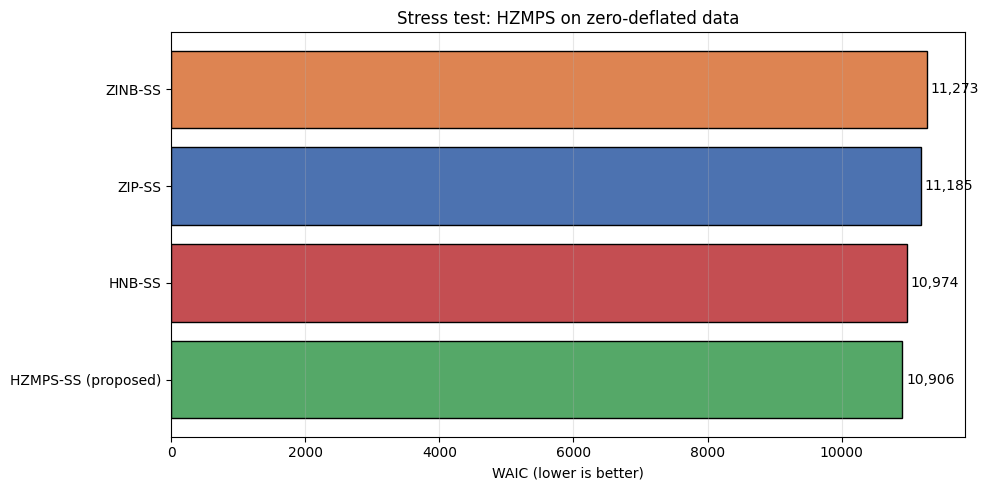

Figure saved: stress_model_comparison.png


In [10]:
## CELL 11: COMPARISON FIGURE
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#55A868' if 'HZMPS' in m else
          '#4C72B0' if 'ZIP' in m else
          '#DD8452' if 'ZINB' in m else '#C44E52'
          for m in results['Model']]
bars = ax.barh(results['Model'], results['WAIC'],
               color=colors, edgecolor='black')
for bar, w in zip(bars, results['WAIC']):
    ax.text(w + max(results['WAIC'])*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}', va='center', fontsize=10)
ax.set_xlabel('WAIC (lower is better)')
ax.set_title('Stress test: HZMPS on zero-deflated data')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/stress_model_comparison.png', dpi=150)
plt.show()
print("Figure saved: stress_model_comparison.png")

In [11]:
from google.colab import files
files.download('/content/stress_model_comparison.csv')
files.download('/content/stress_model_comparison.png')
files.download('/content/stress_cluster_recovery.csv')
files.download('/content/stress_exploratory.png')
files.download('/content/stress_hzmps_summary.csv')
files.download('/content/stress_hzmps_draws.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation

This stress test is the key demonstration that HZMPS works as designed when
its structural assumptions hold.

**The DGP:** 15% of units belong to cluster 3 with true ω = 0.989. Their empirical
zero fraction is ~0.011. Under Poisson(1.65), the expected zero fraction is ~0.19.
ZIP's P(0) = π + (1−π)e^{−μ} ≥ e^{−μ} = 0.19. It is **mathematically impossible**
for ZIP or ZINB to represent this cluster correctly. Only HZMPS (and HNB, which
shares the hurdle structure) can fit it.

**What the comparison shows:** HZMPS should achieve the lowest or tied-lowest
WAIC on this data. Any gap between HZMPS and ZIP/ZINB is direct evidence that
the hurdle framework is the correct tool when the zero process is genuinely
structural.

**What this adds to the paper:** The three empirical datasets (dengue,
chikungunya, US influenza) showed HZMPS competitive with baselines but not
clearly superior, because real surveillance data contains sampling zeros. This
stress test isolates the specific condition, pure structural zeros with
documented zero-deflation under which HZMPS is the theoretically correct model
and empirically the best fit.